In [1]:
import sys
sys.path.append("../")  # Adds the scripts folder to the Python path


In [10]:
pip install --upgrade scikit-learn


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.7 MB 4.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/8.7 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/8.7 MB 5.3 MB/s eta 0:00:01
   -------------------- ------------------- 4.5/8.7 MB 5.3 MB/s eta 0:00:01
   ------------------------- -------------- 5.5/8.7 MB 5.0 MB/s eta 0:00:01
   ------------------------------ --------- 6.6/8.7 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.9/8.7 MB 5.1 MB/s eta 0:00:01
   -------------------------------------- - 8.4/8.7 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 4.9 MB/s  0:00:01

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 2.2.0

    Uninstalling threadpoolctl-2.2.0:

   ---------------------------------------- 0/2 

In [ ]:
# Extra Trees Wind
import pandas as pd
import numpy as np
import time
import os
import joblib
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Paths
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "processed")
MODEL_PATH = os.path.join(PROJECT_ROOT, "models", "ExtraTrees_wind_with_lag_rolling.joblib")
DATA_FILE = "Final_Wind_Data_Model.csv"

# load data 
df = pd.read_csv(os.path.join(DATA_PATH, DATA_FILE), parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# split
split_idx = int(len(df) * 0.8)

df_train_rows = df.iloc[:split_idx].copy()
df_test_rows  = df.iloc[split_idx:].copy()  

# Save aligned test data for future plotting
df_test_rows.to_csv(os.path.join(PROJECT_ROOT, "outputs", "etr_test_alignment.csv"), index=False)

# X/y splits
X_train = df_train_rows.drop(columns=["Date", "Wind_GWh"])
y_train = df_train_rows["Wind_GWh"]

X_test  = df_test_rows.drop(columns=["Date", "Wind_GWh"])
y_test  = df_test_rows["Wind_GWh"]

# Hyperparameter Tuning
param_dist = {
    "n_estimators": [200, 400, 800],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4]
}

etr = ExtraTreesRegressor(random_state=42, n_jobs=-1)
tss = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=etr,
    param_distributions=param_dist,
    n_iter=12,
    cv=tss,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
search.fit(X_train, y_train)
train_duration = round(time.time() - start_time, 2)

best_model = search.best_estimator_

# model save
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(best_model, MODEL_PATH)

# evaluation
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))  
r2 = r2_score(y_test, y_pred)

print(" Best Hyperparameters:", search.best_params_)
print(f" Training Time: {train_duration}s")
print(f" Test  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# TIME
start_infer = time.time()
_ = best_model.predict(X_test.iloc[:1])
infer_time = round(time.time() - start_infer, 4)
print(f" Inference Time (1 sample): {infer_time}s")

print(" Training complete. Model saved.")


In [ ]:
# log
from log_utils import log_model_performance, save_log_to_csv

log_dict = log_model_performance(
    model_name="ExtraTreesRegressor",
    target_variable="Wind_GWh",
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    model_object=best_model,
    training_time_sec=train_duration,
    dataset_name="Final_Wind_Data_Model.csv",
    tuning_type="RandomizedSearchCV + TimeSeriesSplit(5)",
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes="Trained on lag and rolling mean features (chronological split, no leakage)"
)

save_log_to_csv(log_dict)

In [ ]:
# SHAP Analysis for Extra Trees (Wind)
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import os

# Config
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
MODEL_PATH   = os.path.join(PROJECT_ROOT, "models", "ExtraTrees_wind_with_lag_rolling.joblib")
DATA_PATH    = os.path.join(PROJECT_ROOT, "data", "processed", "Final_Wind_Data_Model.csv")

SAVE_DIR     = os.path.join(PROJECT_ROOT, "outputs", "figures", "Etr_shap")
TABLE_PATH   = os.path.join(PROJECT_ROOT, "outputs", "results_tables", "shap_top10_extratrees_wind.csv")
TARGET       = "Wind_GWh"

# Load model & data
model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

X = df.drop(columns=["Date", TARGET])
y = df[TARGET]

# split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# SHAP Explainer 
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)  

#  directories 
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.dirname(TABLE_PATH), exist_ok=True)


# SHAP Summary Bar Plot 

plt.figure()
fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.bar(shap_values, max_display=10, show=False)
for patch in ax.patches:
    patch.set_color('#00b4a2') 
plt.title("SHAP Summary (Extra Trees – Wind_GWh, Test Set)")
plt.tight_layout()
bar_path = os.path.join(SAVE_DIR, "shap_etr_wind_bar.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.close()
print(f" Bar plot saved to: {bar_path}")


# SHAP Beeswarm Plot

plt.figure()
fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
for collection in ax.collections:
    collection.set_facecolor('#00b4a2')  
plt.title("SHAP Beeswarm (Extra Trees – Wind_GWh, Test Set)", fontsize=14)
plt.tight_layout()
beeswarm_path = os.path.join(SAVE_DIR, "shap_etr_wind_beeswarm.png")
plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close()
print(f" Beeswarm plot saved to: {beeswarm_path}")


# Top-10 SHAP Features Table

shap_array = np.abs(shap_values.values)
mean_shap = shap_array.mean(axis=0)
std_shap = shap_array.std(axis=0)

shap_df = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": mean_shap,
    "Std_Dev": std_shap
}).sort_values(by="Mean_SHAP", ascending=False).reset_index(drop=True)

shap_top10 = shap_df.head(10)
shap_top10.index = np.arange(1, len(shap_top10) + 1)
shap_top10.to_csv(TABLE_PATH, index_label="Rank")
print(f" Top-10 features table saved to: {TABLE_PATH}")
print(shap_top10)


In [ ]:
# SHAP Waterfall Plot on Test Set Sample
import shap
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os

# Config
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
MODEL_PATH   = os.path.join(PROJECT_ROOT, "models", "ExtraTrees_wind_with_lag_rolling.joblib")
DATA_PATH    = os.path.join(PROJECT_ROOT, "data", "processed", "Final_Wind_Data_Model.csv")
SAVE_PATH    = os.path.join(PROJECT_ROOT, "outputs", "figures", "Etr_shap", "shap_etr_wind_waterfall_teal_10.png")
TARGET       = "Wind_GWh"
TEAL_GREEN   = "#00b4a2"


model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

X = df.drop(columns=["Date", TARGET])
y = df[TARGET]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# Select sample from test set 
sample_idx = 10  
X_sample = X_test.iloc[[sample_idx]]


explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_sample)

#  Extract explanation object 
explanation = shap.Explanation(
    values=shap_values.values[0],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0],
    feature_names=X_sample.columns.tolist()
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6.5))
shap.plots.waterfall(explanation, max_display=10, show=False)

# Apply teal green color to all bars
for collection in ax.collections:
    try:
        collection.set_facecolor(TEAL_GREEN)
    except:
        pass

plt.title(f"SHAP Waterfall – Extra Trees (Sample {sample_idx}, Test Set)", fontsize=12)
plt.tight_layout()
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f" Waterfall plot saved to: {SAVE_PATH}")


Actual vs predicted on test sample

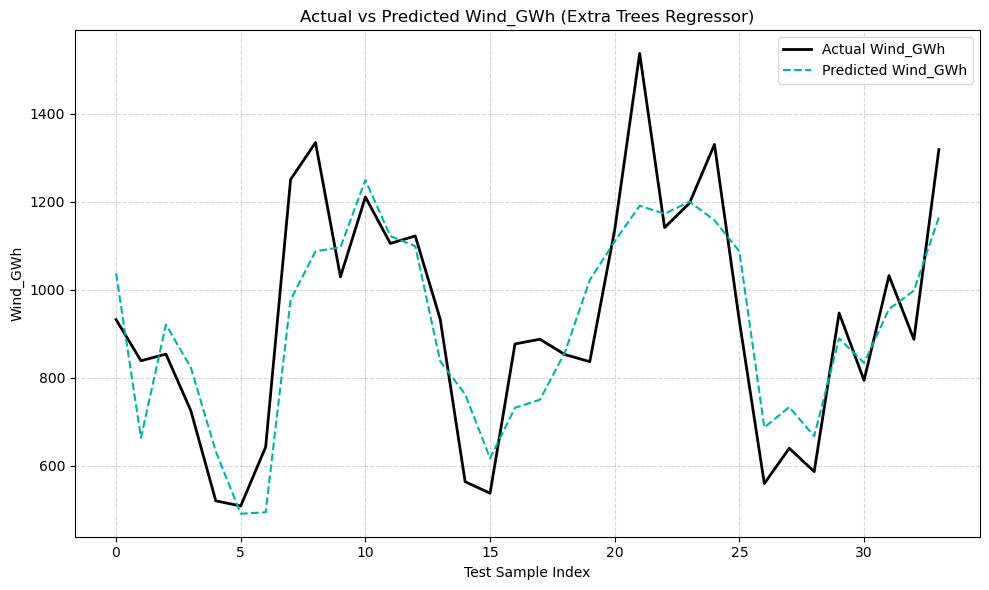

In [ ]:
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label="Actual Wind_GWh", color="#000000", linewidth=2)
plt.plot(y_pred, label="Predicted Wind_GWh", color="#00b4a2", linestyle='--')
plt.title("Actual vs Predicted Wind_GWh (Extra Trees Regressor)")
plt.xlabel("Test Sample Index")
plt.ylabel("Wind_GWh")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save
output_path = os.path.join(PROJECT_ROOT, "outputs", "figures", "extratrees_actual_vs_predicted.png")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
plt.savefig(output_path, dpi=300)
plt.show()


In [46]:
train_df = pd.DataFrame({
    "Actual": y_train.values,
    "Predicted": y_train_pred
})
print(train_df.head(10))


    Actual   Predicted
0  274.802  274.725416
1  354.989  354.989000
2  205.538  205.566575
3  245.734  245.733872
4  542.454  542.454000
5  242.292  242.296303
6  184.921  184.921000
7  190.237  190.237000
8  483.044  483.044000
9  450.738  450.744593


In [ ]:
# Predict on test set
y_test_pred = best_model.predict(X_test)

# Created DataFrame with index preserved for reference
test_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}, index=y_test.index)

# Show first 10 rows
print(test_df.head(10))

# Save to outputs/results directory 
results_path = os.path.join(PROJECT_ROOT, "outputs", "results_tables")
os.makedirs(results_path, exist_ok=True)

output_file = os.path.join(results_path, "extratrees_wind_test_results.csv")
test_df.to_csv(output_file, index_label="Row_Index")

print(f" Test results saved to: {output_file}")


Without Hyperparameter Tuning (Baseline Extra Trees)

In [ ]:
#  Baseline Extra Trees (No Tuning)
import os
import time
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Config 
PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"
DATA_PATH    = os.path.join(PROJECT_ROOT, "data", "processed")
DATA_FILE    = "Final_Wind_Data_Model.csv"
MODEL_PATH   = os.path.join(PROJECT_ROOT, "models", "ExtraTrees_Wind_Baseline.joblib")

RESULTS_DIR  = os.path.join(PROJECT_ROOT, "outputs", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

#  Load & sort by time
df = pd.read_csv(os.path.join(DATA_PATH, DATA_FILE), parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Raw features only (no lags/rolling)
raw_features = ["Wind_Speed_10m", "Temperature_Celsius", "Cloud_Cover", "Wind_Capacity_MW"]
X_full = df[raw_features]
y_full = df["Wind_GWh"]

# split 
split_idx = int(len(df) * 0.80)
df_train_rows = df.iloc[:split_idx].copy()
df_test_rows  = df.iloc[split_idx:].copy()   

X_train = X_full.iloc[:split_idx]
X_test  = X_full.iloc[split_idx:]
y_train = y_full.iloc[:split_idx]
y_test  = y_full.iloc[split_idx:]

# Train baseline model 
etr = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
etr.fit(X_train, y_train)
train_duration = round(time.time() - t0, 2)

#  Save model 
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(etr, MODEL_PATH)

y_pred = etr.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = r2_score(y_test, y_pred)

print(" Extra Trees Baseline Model (No Tuning)")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:  {r2:.3f}")
print(f"Training Time: {train_duration} seconds")
print(f"Model saved to: {MODEL_PATH}")

#  Save aligned test predictions (with Date) 
preds_path = os.path.join(RESULTS_DIR, "extratrees_wind_baseline_test_results.csv")
test_out = pd.DataFrame({
    "Date": df_test_rows["Date"].values,
    "Actual_Wind_GWh": y_test.values,
    "Pred_Wind_GWh": y_pred
})
test_out.to_csv(preds_path, index=False)
print(f" Test predictions saved: {preds_path}")


In [ ]:
from log_utils import log_model_performance, save_log_to_csv

#  Log performance 
log_dict = log_model_performance(
    model_name="ExtraTrees_Wind_Baseline",
    target_variable="Wind_GWh",
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    model_object=etr, 
    training_time_sec=train_duration,
    dataset_name="Final_Wind_Data_Model.csv",
    tuning_type="NA",  
    gpu_used="NVIDIA GeForce RTX 2050",
    extra_notes="Trained on dataset without Lags and Rolling"
)

save_log_to_csv(log_dict)
print(" Baseline model performance logged successfully.")


Plot and Save Actual vs Predicted (Extra Trees Baseline)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = r"C:\Projects\GitHub\Ireland-energy-forecast"

FIG_DIR   = os.path.join(PROJECT_ROOT, "outputs", "figures")
TABLE_DIR = os.path.join(PROJECT_ROOT, "outputs", "results_tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)


# Test set

y_pred_test = etr.predict(X_test)

test_df = pd.DataFrame(
    {"Actual": y_test.values, "Predicted": y_pred_test},
    index=y_test.index
)

# Save CSV
test_csv = os.path.join(TABLE_DIR, "etr_baseline_actual_vs_pred_test.csv")
test_df.to_csv(test_csv, index_label="Index")
print(f" Saved TEST Actual vs Predicted to:\n{test_csv}")

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(test_df["Actual"].values,    label="Actual Wind_GWh",    color="#000000", linewidth=2)
plt.plot(test_df["Predicted"].values, label="Predicted Wind_GWh", color="#00b4a2", linestyle="--", linewidth=2)
plt.title("Extra Trees Baseline — Test: Actual vs Predicted Wind_GWh")
plt.xlabel("Test Sample Index")
plt.ylabel("Wind_GWh")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

test_fig = os.path.join(FIG_DIR, "etr_baseline_actual_vs_pred_test.png")
plt.savefig(test_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f" Saved TEST plot to:\n{test_fig}")
